<a href="https://colab.research.google.com/github/ticiAngelucci/GuiaLaboratorioQuantum/blob/main/modulo1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

El "Quantum Sandbox": Tu Laboratorio Visual

Antes de escribir una sola línea de código en Python, utilizaremos la herramienta interactiva de QHub para desarrollar la intuición física.

Instrucciones de uso:

    Ingresá en el siguiente enlace: https://www.qhubperu.com/aprendizaje/modulo4

    Una vez en la página, hacé scroll hacia abajo hasta encontrar la sección titulada: "TU PRIMER CIRCUITO CUÁNTICO !".

    Utilizá el editor visual allí presente para los desafíos de cada módulo.

Acto 0: Azar y Medición

"Entendiendo el qubit."
Utilizando el sandbox visual, construye un circuito con un solo qubit.

    ¿Qué compuertas necesitas usar para que al medir el qubit, obtengas siempre el estado ∣0⟩? ¿Y para obtener siempre ∣1⟩?

    Observa los diagramas de probabilidad (los gráficos de barras). ¿Cómo cambian cuando aplicas una compuerta H (Hadamard)? Relaciona esto con el concepto de una variable aleatoria de Bernoulli con p=0.5.

Ahora si seguimos con codigo:

In [ ]:
#Qiskit (abreviación de Quantum Information Software Kit) es, básicamente, el "lenguaje"
# estándar de la industria para programar computadoras cuánticas,desarrollado por IBM que
#te permite crear, manipular y ejecutar circuitos cuánticos, ya sea en un simulador dentro
#de tu propia computadora o en una computadora cuántica real alojada en los laboratorios de IBM en la nube.

#Instalar Qiskit en el notebook
!pip install qiskit qiskit-aer

In [ ]:
#Acto 1 (Moneda Clásica)
#Una variable aleatoria de Bernoulli X toma el valor 1 (cara) con probabilidad p
# y 0 (cruz) con probabilidad 1−p. Cada vez que ejecutemos este codigo sale
# un valor diferente.
import numpy as np
import matplotlib.pyplot as plt

def simulacion_moneda_clasica(p, n_lanzamientos):
    # Generamos n_lanzamientos siguiendo una distribución de Bernoulli
    # np.random.choice elige entre [0, 1] con probabilidades [1-p, p]
    resultados = np.random.choice([0, 1], size=n_lanzamientos, p=[1-p, p])
    return resultados

# Parámetros
p_teorica = 0.7  # La moneda está trucada: 70% de probabilidad de salir 1
n = 1000

# Ejecución
resultados_clasicos = simulacion_moneda_clasica(p_teorica, n)
frecuencia_relativa = np.sum(resultados_clasicos) / n

print(f"Probabilidad teórica de obtener 1: {p_teorica}")
print(f"Frecuencia experimental (clásica): {frecuencia_relativa}")

Probabilidad teórica de obtener 1: 0.7
Frecuencia experimental (clásica): 0.678


In [ ]:
# Acto 2:El Salto Cuántico (Qubit como Moneda)
#En cuántica, el estado está definido por ∣ψ⟩=α∣0⟩+β∣1⟩.
#La probabilidad de medir 0 es ∣α∣^2 y la de medir 1 es ∣β∣^2.
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

# Definimos alpha y beta.
# Para que |alpha|^2 + |beta|^2 = 1, probemos alpha = sqrt(0.3) y beta = sqrt(0.7)
alpha = np.sqrt(0.3)
beta = np.sqrt(0.7)

# Creamos circuito
qc = QuantumCircuit(1)
# Inicializamos el estado |psi>
qc.initialize([alpha, beta], 0)
qc.measure_all()

# Simulamos
simulator = AerSimulator()
job = simulator.run(transpile(qc, simulator), shots=1000)
counts = job.result().get_counts()

# Obtenemos la frecuencia experimental del estado |1>
frec_experimental_cuantica = counts.get('1', 0) / 1000

print(f"Probabilidad teórica (Regla de Born |beta|^2): {beta**2}")
print(f"Frecuencia experimental (Cuántica): {frec_experimental_cuantica}")

Probabilidad teórica (Regla de Born |beta|^2): 0.7000000000000001
Frecuencia experimental (Cuántica): 0.704


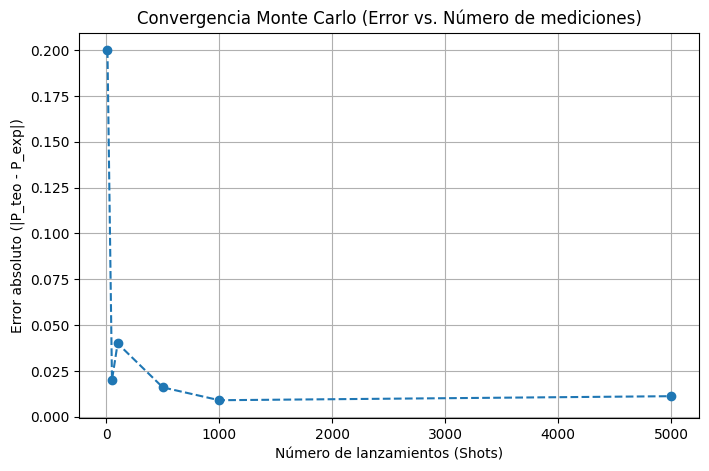

In [ ]:
#Acto 3: Análisis Monte Carlo (Convergencia)
#Aquí es donde unimos todo: ¿Cómo la estadística frecuencial nos demuestra que
#el sistema cuántico "se porta bien"? Vamos a ver cómo el error entre la teoría
#y la práctica disminuye al aumentar N.
shots_range = [10, 50, 100, 500, 1000, 5000]
errores = []

for shots in shots_range:
    job = simulator.run(transpile(qc, simulator), shots=shots)
    counts = job.result().get_counts()

    # Probabilidad experimental medida
    p_exp = counts.get('1', 0) / shots
    # Error absoluto respecto a la teoría (|beta|^2 = 0.7)
    error = abs(p_exp - 0.7)
    errores.append(error)

# Graficamos la convergencia
plt.figure(figsize=(8, 5))
plt.plot(shots_range, errores, marker='o', linestyle='--')
plt.title("Convergencia Monte Carlo (Error vs. Número de mediciones)")
plt.xlabel("Número de lanzamientos (Shots)")
plt.ylabel("Error absoluto (|P_teo - P_exp|)")
plt.grid(True)
plt.show()

Notas:

    Observación: En el gráfico anterior, verán que a medida que aumentan los shots, el error tiende a cero. Esto es la Ley de los Grandes Números.

    Conclusión: La naturaleza probabilística de la medición cuántica no es "caótica"; sigue las mismas leyes estadísticas que un proceso clásico. La única diferencia es que el "parámetro p" es controlado mediante el estado cuántico ∣ψ⟩ en el Espacio de Hilbert.

**Sección de Práctica: Desafíos de Laboratorio**

Desafío 1: El Sintonizador de Probabilidades

    Tu objetivo es preparar una moneda cuántica trucada que resulte en un 25% de probabilidad de '1'. Modifica los valores de alpha y beta para lograrlo. Pista: Recuerda que ∣β∣^2=P(1).

    Pregunta de reflexión: "¿Qué pasa si eliges valores donde la suma de los cuadrados sea mayor a 1? ¿Qué error arroja Qiskit y por qué crees que ocurre?"

Desafío 2: Visualización en la Esfera de Bloch

La estadística es abstracta, pero la cuántica tiene una geometría hermosa. Agreguen este código debajo de la Parte 2(Solo funciona si tienes el estado guardado en el simulador):

`from qiskit.visualization import plot_bloch_multivector`

`plot_bloch_multivector(qc)`

    Ejecuta este código y observa el vector resultante. Luego, cambia alpha y beta a 1/sqrt(2) (estado ∣+⟩) y vuelve a ejecutar. ¿Hacia dónde apunta el vector ahora?

    ¿Cómo se relaciona la posición del vector en la esfera con la probabilidad de medir 0 o 1?

Desafío 3: El experimento de las muestras pequeñas vs. grandes

En la Parte 3 (Monte Carlo):

    Ejecuta la simulación con shots = 5 y luego con shots = 10000. Ejecuta la celda 5 veces seguidas para cada caso.

    Pregunta de reflexión: "¿Por qué con 5 tiros los resultados varían tanto entre una ejecución y otra, mientras que con 10,000 son casi iguales? ¿Cómo se vincula esto con el concepto de varianza que vimos en clase?"

Desafío 4: El "Estado Misterioso" (Inferencia)

Esta es la prueba de fuego.

    Borra el código donde inicializas el qubit. Ahora, te doy este resultado de conteo: {'0': 250, '1': 750}. Sin saber el estado original, ¿puedes deducir cuáles eran los valores aproximados de alpha y beta? Escribe un código que, dado ese resultado, intente recrear el estado inicial.

    Objetivo: Esto les enseña que en la vida real (en un laboratorio de física), nosotros medimos primero y deducimos el estado después.
Preguntas Reflexivas

    ¿Qué sucede con la diferencia entre la probabilidad teórica y la experimental a medida que aumentamos el número de shots de 100 a 10,000? ¿Cómo se relaciona esto con lo que vimos en clase sobre la convergencia de variables aleatorias?"
